#### steps to create Ml Model

###### 1) EDA- exploratory Data analysis
###### 2) Data Cleaning
###### 3) Data preprocessing 
###### 4) Feature Engineering 
###### 5) Feature Selection 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 


warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("insurance (1).csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


##### feature engineering and extraction 


<Axes: xlabel='bmi', ylabel='Count'>

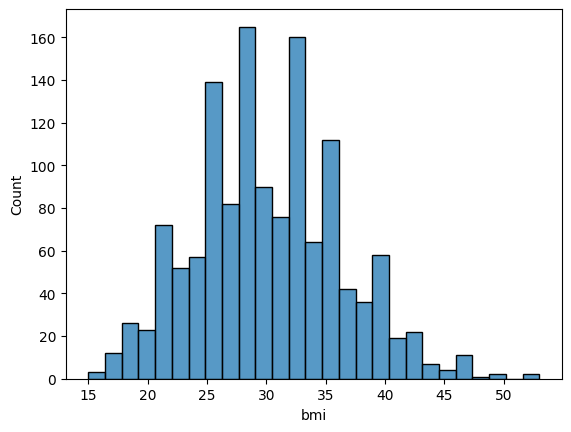

In [35]:
sns.histplot(df_cleaned["bmi"])

In [36]:
df_cleaned["bmi_Category"] = pd.cut(
    df_cleaned["bmi"],
    bins= [0,18.5,24.9, 29.9,float("inf")],
    labels=["Underweight","Normal","Overweight","Obese"]
)

In [37]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [38]:
df_cleaned=pd.get_dummies(df_cleaned,columns=["bmi_Category"],drop_first=True)

In [39]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese
0,19,1,27,0,1,16884,0,0,1,False,True,False
1,18,0,33,1,0,1725,0,1,0,False,False,True
2,28,0,33,3,0,4449,0,1,0,False,False,True
3,33,0,22,0,0,21984,1,0,0,True,False,False
4,32,0,28,0,0,3866,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,False,False,True
1334,18,1,31,0,0,2205,0,0,0,False,False,True
1335,18,1,36,0,0,1629,0,1,0,False,False,True
1336,21,1,25,0,0,2007,0,0,1,False,True,False


In [40]:
 df_cleaned=df_cleaned.astype(int)

In [41]:
df_cleaned

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,0,0,1
1334,18,1,31,0,0,2205,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,1,0,0,0,1
1336,21,1,25,0,0,2007,0,0,1,0,1,0


##### Feature Scaling 

In [42]:
df_cleaned.columns

Index(['age', 'isFemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_Category_Normal', 'bmi_Category_Overweight', 'bmi_Category_Obese'],
      dtype='str')

In [43]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [45]:
from sklearn.preprocessing import StandardScaler

In [46]:
cols = ["age","bmi","children"]
scaler = StandardScaler()
df_cleaned[cols]= scaler.fit_transform(df_cleaned[cols])
df_cleaned.head()

,age,isFemale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,bmi_Category_Normal,bmi_Category_Overweight,bmi_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0


In [47]:
from scipy.stats import pearsonr
# pearson correlation  calculation 
# pearson correlation values lies between -1 to 1

# List of features to check against target
selected_features = [
"age","bmi", "children", "isFemale", "isSmoker", "region_northwest","region_southeast","region_southwest","bmi_Category_Normal","bmi_Category_Overweight", "bmi_Category_Obese"
]

correlations = {
    feature : pearsonr(df_cleaned[feature], df_cleaned["charges"])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(list(correlations.items()),columns = ["Feature", "Pearson Correlation "])
correlation_df.sort_values(by = "Pearson Correlation ", ascending = False)


,Feature,Pearson Correlation
4,isSmoker,0.787234
0,age,0.298309
10,bmi_Category_Obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
5,region_northwest,-0.038695
7,region_southwest,-0.043637
3,isFemale,-0.058046
8,bmi_Category_Normal,-0.104042


In [48]:
# here are categorical fesatures 
cat_features=[
     "isFemale", "isSmoker", "region_northwest","region_southeast","region_southwest","bmi_Category_Normal","bmi_Category_Overweight", "bmi_Category_Obese"
]

In [49]:
from scipy.stats import chi2_contingency
import pandas as pd 
 
alpha = 0.05

df_cleaned["charges_bin"]= pd.qcut(df_cleaned["charges"], q=4 , labels = False )
chi2_results= {}


for col in cat_features:

    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])

    chi2_stat, p_val,_,_ = chi2_contingency(contingency_table)
    decision = "Reject Null (Keep Feature)" if p_val < alpha else "Accept Null (Drop Feature)"
    chi2_results[col]={
"chi2_statistic": chi2_stat,
"p_value":p_val,
"Decision": decision 
    }

    chi2_df = pd.DataFrame(chi2_results).T
    chi2_df = chi2_df.sort_values(by="p_value")
    chi2_df


In [50]:
chi2_df

,chi2_statistic,p_value,Decision
isSmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isFemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_Category_Obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_Category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_Category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [51]:
final_df = df_cleaned[["age","isFemale", "bmi","children","isSmoker","charges", "region_southeast","bmi_Category_Obese"  ]]

In [52]:
final_df

,age,isFemale,bmi,children,isSmoker,charges,region_southeast,bmi_Category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
